# Basin Transfer Matrix & Similarity Analysis
**Goal:**
1. Build a 6×6 transfer matrix — train on each basin, test on each other.
2. Measure statistical similarity between basins (MMD).
3. Find the minimum source basin set for each target basin.

In [40]:
# ── Setup ─────────────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "cartopy", "seaborn", "-q"], capture_output=True)

import os, sys
from pathlib import Path

REPO = "https://github.com/Thiruvikraman07/ClimateChangeFinalProject"
ROOT = Path("/content/ClimateChangeFinalProject")
if not ROOT.exists():
    subprocess.run(["git", "clone", REPO, str(ROOT)], check=True)
else:
    subprocess.run(["git", "-C", str(ROOT), "pull"], check=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from google.colab import drive
drive.mount("/content/drive")
DATA_ROOT = Path("/content/drive/MyDrive/MLfTCC/Data/Tropicyclonenet/TestData/TCND_test")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import importlib, src.data.dataset, src.models.lstm_seq2seq, src.training.trainer, src.training.metrics
for m in [src.data.dataset, src.models.lstm_seq2seq, src.training.trainer, src.training.metrics]:
    importlib.reload(m)

from src.data.dataset import TCTrackDataset, BASINS, BASIN2IDX
from src.data.utils import TRAIN_YEARS, VAL_YEARS, TEST_YEARS, haversine_km, denorm_lon, denorm_lat
from src.models.lstm_seq2seq import LSTMSeq2SeqAttn
from src.training.trainer import Trainer
from src.training.metrics import evaluate_dataset, evaluate_by_basin

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
(RESULTS / "checkpoints").mkdir(exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASIN_COLORS = {"EP":"#2563eb","NA":"#dc2626","NI":"#d97706","SI":"#16a34a","SP":"#7c3aed","WP":"#0891b2"}
print("Device:", DEVICE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [41]:
# Load all datasets (cached after first run)
train_ds = TCTrackDataset(DATA_ROOT, train_years=TRAIN_YEARS, cache_dir="/content")
val_ds   = TCTrackDataset(DATA_ROOT, train_years=VAL_YEARS,   cache_dir="/content")
test_ds  = TCTrackDataset(DATA_ROOT, train_years=TEST_YEARS,  cache_dir="/content")
print(train_ds.basin_stats().to_string(index=False))

Loading dataset from cache: tcdataset_9c99a2d89e.pkl
  6805 samples loaded instantly.
Loading dataset from cache: tcdataset_27e4d1eb3b.pkl
  1697 samples loaded instantly.
Loading dataset from cache: tcdataset_6be8e1b131.pkl
  2242 samples loaded instantly.
basin  n_samples  n_tcs
   EP       1259     57
   NA       1585     65
   NI        253     15
   SI       1231     53
   SP        418     18
   WP       2059    103


In [42]:
# Per-basin dataset splits — used by MMD, transfer matrix, and greedy selection cells
per_basin_train = {
    b: TCTrackDataset(DATA_ROOT, basins=[b], train_years=TRAIN_YEARS, cache_dir="/content")
    for b in BASINS
}
per_basin_val = {
    b: TCTrackDataset(DATA_ROOT, basins=[b], train_years=VAL_YEARS, cache_dir="/content")
    for b in BASINS
}
per_basin_test = {
    b: TCTrackDataset(DATA_ROOT, basins=[b], train_years=TEST_YEARS, cache_dir="/content")
    for b in BASINS
}

print("Per-basin sample counts (train / val / test):")
for b in BASINS:
    print(f"  {b}: {len(per_basin_train[b])} / {len(per_basin_val[b])} / {len(per_basin_test[b])}")

Building dataset index from 104 TC files (first run — will cache)...
  [1/104] EP ...
  [50/104] EP ...
  [100/104] EP ...
  Done — 1259 windows from 104 TCs.
  Cached to /content/tcdataset_f8a965e8e8.pkl for fast reloads.
Building dataset index from 108 TC files (first run — will cache)...
  [1/108] NA ...
  [50/108] NA ...
  [100/108] NA ...
  Done — 1585 windows from 108 TCs.
  Cached to /content/tcdataset_f83d06b61e.pkl for fast reloads.
Building dataset index from 20 TC files (first run — will cache)...
  [1/20] NI ...
  Done — 253 windows from 20 TCs.
  Cached to /content/tcdataset_6ddad8cc4c.pkl for fast reloads.
Building dataset index from 81 TC files (first run — will cache)...
  [1/81] SI ...
  [50/81] SI ...
  Done — 1231 windows from 81 TCs.
  Cached to /content/tcdataset_64fe3b62d6.pkl for fast reloads.
Building dataset index from 30 TC files (first run — will cache)...
  [1/30] SP ...
  Done — 418 windows from 30 TCs.
  Cached to /content/tcdataset_593ecf3a67.pkl for fast

## Section 1 — Statistical Basin Similarity (MMD)

**Maximum Mean Discrepancy (MMD)** measures how different two distributions are.
We compute it on the mean obs features per sample:
- If MMD is small → basins have similar feature distributions → transfer should be easier
- If MMD is large → basins are very different → transfer is harder

MMD formula: MMD²(P,Q) = E[k(x,x')] - 2E[k(x,y)] + E[k(y,y')]
where k is an RBF kernel and x~P, y~Q.

Computing MMD between all basin pairs...


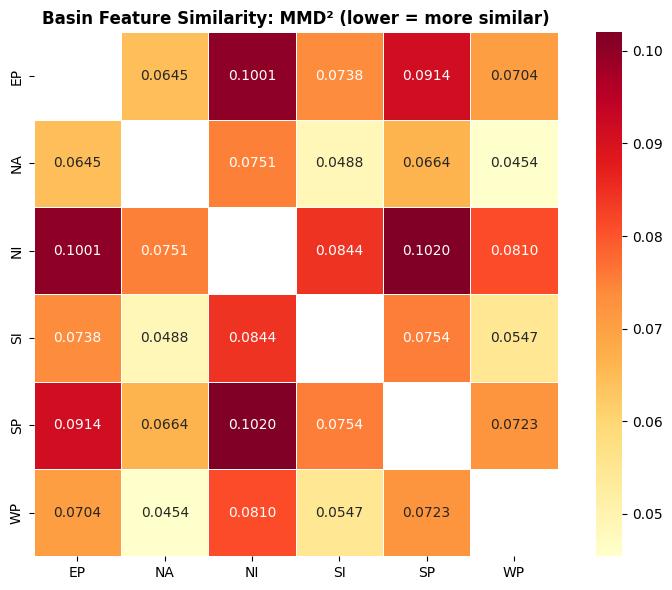


Most similar basin pairs (lowest MMD²):
  NA ↔ WP: MMD²=0.0454
  NA ↔ SI: MMD²=0.0488
  SI ↔ WP: MMD²=0.0547
  EP ↔ NA: MMD²=0.0645

Most dissimilar basin pairs:
  NI ↔ SP: MMD²=0.1020
  EP ↔ NI: MMD²=0.1001
  EP ↔ SP: MMD²=0.0914
  NI ↔ SI: MMD²=0.0844


In [43]:
def compute_mmd(X: np.ndarray, Y: np.ndarray, sigma: float = 1.0) -> float:
    """
    Unbiased estimate of MMD² between samples X and Y using RBF kernel.
    X, Y: (n, d) arrays of feature vectors.
    """
    def rbf_kernel(A, B, s):
        diff = A[:, None, :] - B[None, :, :]
        sq = (diff ** 2).sum(-1)
        return np.exp(-sq / (2 * s ** 2))

    n, m = len(X), len(Y)
    Kxx = rbf_kernel(X, X, sigma)
    Kyy = rbf_kernel(Y, Y, sigma)
    Kxy = rbf_kernel(X, Y, sigma)

    # Unbiased: subtract diagonal from XX and YY
    mmd2 = (Kxx.sum() - np.diag(Kxx).sum()) / (n*(n-1)) \
         + (Kyy.sum() - np.diag(Kyy).sum()) / (m*(m-1)) \
         - 2 * Kxy.mean()
    return float(max(mmd2, 0.0))

def get_basin_features(ds, max_samples=500) -> np.ndarray:
    """Extract mean obs features per sample."""
    feats = []
    for s in ds.samples[:max_samples]:
        obs = s["obs"]  # (8, 4)
        feats.append(obs.mean(axis=0))  # mean over time
    return np.array(feats)

# Compute MMD between all basin pairs
print("Computing MMD between all basin pairs...")
mmd_matrix = np.zeros((6, 6))
basin_feats = {b: get_basin_features(per_basin_train[b]) for b in BASINS}

for i, b1 in enumerate(BASINS):
    for j, b2 in enumerate(BASINS):
        if i == j:
            mmd_matrix[i, j] = 0.0
        elif i < j:
            mmd = compute_mmd(basin_feats[b1], basin_feats[b2], sigma=0.5)
            mmd_matrix[i, j] = mmd
            mmd_matrix[j, i] = mmd

mmd_df = pd.DataFrame(mmd_matrix, index=BASINS, columns=BASINS)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.eye(6, dtype=bool)
sns.heatmap(mmd_df, annot=True, fmt=".4f", cmap="YlOrRd", ax=ax, mask=mask,
            linewidths=0.5, square=True)
ax.set_title("Basin Feature Similarity: MMD² (lower = more similar)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS / "fig_basin_mmd.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nMost similar basin pairs (lowest MMD²):")
pairs = [(mmd_matrix[i,j], BASINS[i], BASINS[j]) for i in range(6) for j in range(i+1,6)]
for mmd, b1, b2 in sorted(pairs)[:4]:
    print(f"  {b1} ↔ {b2}: MMD²={mmd:.4f}")
print("\nMost dissimilar basin pairs:")
for mmd, b1, b2 in sorted(pairs, reverse=True)[:4]:
    print(f"  {b1} ↔ {b2}: MMD²={mmd:.4f}")

## Section 2 — Pairwise Transfer Matrix

Train a single-source model on each basin, then test on each other basin.
This gives a 6×6 matrix: row = source basin, column = target basin.

**Key questions answered:**
- Which single source basin generalizes best?
- Is transfer asymmetric? (Does WP → NI transfer better than NI → WP?)

In [44]:
from torch.utils.data import ConcatDataset
from src.models.lstm_seq2seq import LSTMSeq2SeqAttn
from src.training.trainer import Trainer
from src.training.metrics import evaluate_dataset

def train_and_eval_transfer(source_basins, target_basin, name, max_epochs=40):
    """Train on source_basins, evaluate on target_basin test set."""
    # Validation: use a mix of source basins val years
    train_ds = TCTrackDataset(DATA_ROOT, basins=source_basins, train_years=TRAIN_YEARS, cache_dir="/content")
    val_ds   = TCTrackDataset(DATA_ROOT, basins=source_basins, train_years=VAL_YEARS,   cache_dir="/content")
    test_ds  = per_basin_test[target_basin]

    if len(train_ds) < 50 or len(test_ds) < 5:
        return {"ade_km": float("nan"), "fde_km": float("nan")}

    tl  = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=2)
    vl  = DataLoader(val_ds,   batch_size=128, shuffle=False, num_workers=2)
    tstl= DataLoader(test_ds,  batch_size=128, shuffle=False, num_workers=2)

    model = LSTMSeq2SeqAttn(obs_feat_dim=6, hidden_dim=128, pred_len=4,
                             n_basins=6, basin_emb_dim=16, num_layers=2).to(DEVICE)
    trainer = Trainer(model, tl, vl, DEVICE, lr=1e-3, max_epochs=max_epochs, patience=8,
                      save_dir=str(RESULTS/"checkpoints"), experiment_name=name)
    trainer.train(verbose=False)
    trainer.load_best()

    return evaluate_dataset(model, tstl, DEVICE)

# Compute full 6x6 transfer matrix
print("Computing 6x6 transfer matrix (this takes a while — one model per source basin)...")
transfer_ade = np.full((6, 6), np.nan)

for src_i, src_basin in enumerate(BASINS):
    print(f"\n--- Source: {src_basin} ---")
    for tgt_j, tgt_basin in enumerate(BASINS):
        name = f"transfer_{src_basin}_to_{tgt_basin}"
        metrics = train_and_eval_transfer([src_basin], tgt_basin, name, max_epochs=40)
        transfer_ade[src_i, tgt_j] = metrics.get("ade_km", np.nan)
        print(f"  → {tgt_basin}: ADE={metrics.get('ade_km', float('nan')):.1f} km")

np.save(str(RESULTS/"transfer_matrix.npy"), transfer_ade)

Computing 6x6 transfer matrix (this takes a while — one model per source basin)...

--- Source: EP ---
Loading dataset from cache: tcdataset_f8a965e8e8.pkl
  1259 samples loaded instantly.
Loading dataset from cache: tcdataset_9a34cda7b0.pkl
  261 samples loaded instantly.

Training: transfer_EP_to_EP
  Device: cuda
  Params: 451,299
  Train batches: 10, Val batches: 3

Early stopping at epoch 24 (best=23)

Training complete. Best val_loss=0.00316 at epoch 23
Loaded best model from epoch 23 (val_loss=0.00316)
  → EP: ADE=904.9 km
Loading dataset from cache: tcdataset_f8a965e8e8.pkl
  1259 samples loaded instantly.
Loading dataset from cache: tcdataset_9a34cda7b0.pkl
  261 samples loaded instantly.

Training: transfer_EP_to_NA
  Device: cuda
  Params: 451,299
  Train batches: 10, Val batches: 3

Early stopping at epoch 20 (best=17)

Training complete. Best val_loss=0.00322 at epoch 17
Loaded best model from epoch 17 (val_loss=0.00322)
  → NA: ADE=2083.6 km
Loading dataset from cache: tc

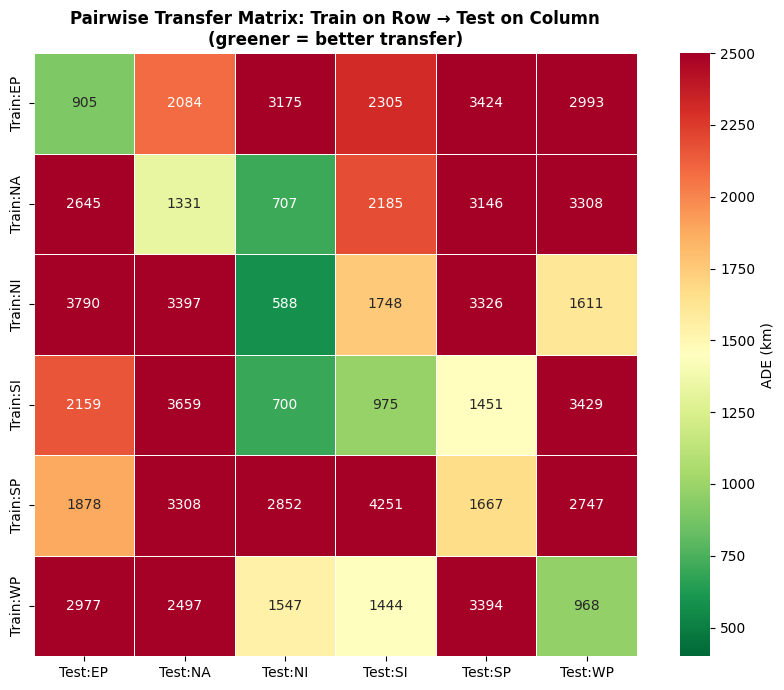


Best single-basin source for each target:
  EP ← best source: SP (ADE=1878.1 km)
  NA ← best source: EP (ADE=2083.6 km)
  NI ← best source: SI (ADE=700.3 km)
  SI ← best source: WP (ADE=1444.4 km)
  SP ← best source: SI (ADE=1450.8 km)
  WP ← best source: NI (ADE=1611.1 km)


In [45]:
transfer_ade = np.load(str(RESULTS/"transfer_matrix.npy"))
transfer_df = pd.DataFrame(transfer_ade, index=[f"Train:{b}" for b in BASINS],
                                          columns=[f"Test:{b}" for b in BASINS])

fig, ax = plt.subplots(figsize=(9, 7))
# Mask diagonal (same basin train/test)
annot = np.where(np.isnan(transfer_ade), "", transfer_ade.round(0).astype(int).astype(str))
sns.heatmap(transfer_ade, annot=annot, fmt="s", cmap="RdYlGn_r", ax=ax,
            xticklabels=[f"Test:{b}" for b in BASINS],
            yticklabels=[f"Train:{b}" for b in BASINS],
            linewidths=0.5, square=True, vmin=400, vmax=2500,
            cbar_kws={"label": "ADE (km)"})
ax.set_title("Pairwise Transfer Matrix: Train on Row → Test on Column\n(greener = better transfer)", 
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS / "fig_transfer_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nBest single-basin source for each target:")
for j, tgt in enumerate(BASINS):
    col = transfer_ade[:, j].copy()
    col[j] = np.nan  # exclude self
    best_i = int(np.nanargmin(col))
    print(f"  {tgt} ← best source: {BASINS[best_i]} (ADE={col[best_i]:.1f} km)")

## Section 3 — Minimum Source Basin Selection

**Question:** For each target basin, what is the *smallest subset* of source basins that achieves performance within 10% of the full 5-basin LOBO model?

This uses a greedy forward selection approach:
1. Start with the single best source basin.
2. Add the source that gives the biggest ADE improvement.
3. Stop when additional basins stop helping (< 5% relative improvement).

In [46]:
from src.training.metrics import evaluate_by_basin

def greedy_basin_selection(target_basin, max_sources=5, patience_pct=5.0):
    """
    Greedy forward selection of source basins for a given target.
    Returns list of (source_set, ADE) tuples.
    """
    available = [b for b in BASINS if b != target_basin]
    selected = []
    results = []
    best_ade = float("inf")

    for step in range(min(max_sources, len(available))):
        step_results = []
        for candidate in available:
            if candidate in selected:
                continue
            source_set = selected + [candidate]
            name = f"greedy_{target_basin}_{''.join(sorted(source_set))}"
            metrics = train_and_eval_transfer(source_set, target_basin, name, max_epochs=30)
            step_results.append((candidate, metrics.get("ade_km", float("inf"))))
            print(f"  {'+'.join(sorted(source_set))} → {target_basin}: ADE={metrics.get('ade_km',999):.1f}")

        # Pick best candidate
        best_cand, best_cand_ade = min(step_results, key=lambda x: x[1])
        improvement = (best_ade - best_cand_ade) / best_ade * 100 if best_ade < float("inf") else 100

        selected.append(best_cand)
        available = [b for b in available if b != best_cand]
        results.append((list(selected), best_cand_ade))
        best_ade = best_cand_ade
        print(f"  → Added {best_cand}, ADE={best_cand_ade:.1f} km (Δ={improvement:+.1f}%)")

        if improvement < patience_pct and step > 0:
            print(f"  → Stopping: improvement < {patience_pct}%")
            break

    return results

# Run greedy selection for sparse basins
print("Greedy source basin selection for NI (North Indian)...")
ni_results = greedy_basin_selection("NI")

print("\nGreedy source basin selection for SP (South Pacific)...")
sp_results = greedy_basin_selection("SP")

Greedy source basin selection for NI (North Indian)...
Loading dataset from cache: tcdataset_f8a965e8e8.pkl
  1259 samples loaded instantly.
Loading dataset from cache: tcdataset_9a34cda7b0.pkl
  261 samples loaded instantly.

Training: greedy_NI_EP
  Device: cuda
  Params: 451,299
  Train batches: 10, Val batches: 3

Early stopping at epoch 23 (best=15)

Training complete. Best val_loss=0.00342 at epoch 15
Loaded best model from epoch 15 (val_loss=0.00342)
  EP → NI: ADE=4860.9
Loading dataset from cache: tcdataset_f83d06b61e.pkl
  1585 samples loaded instantly.
Loading dataset from cache: tcdataset_375ed169d4.pkl
  360 samples loaded instantly.

Training: greedy_NI_NA
  Device: cuda
  Params: 451,299
  Train batches: 13, Val batches: 3

Training complete. Best val_loss=0.01769 at epoch 30
Loaded best model from epoch 30 (val_loss=0.01769)
  NA → NI: ADE=2747.7
Loading dataset from cache: tcdataset_64fe3b62d6.pkl
  1231 samples loaded instantly.
Loading dataset from cache: tcdataset_2

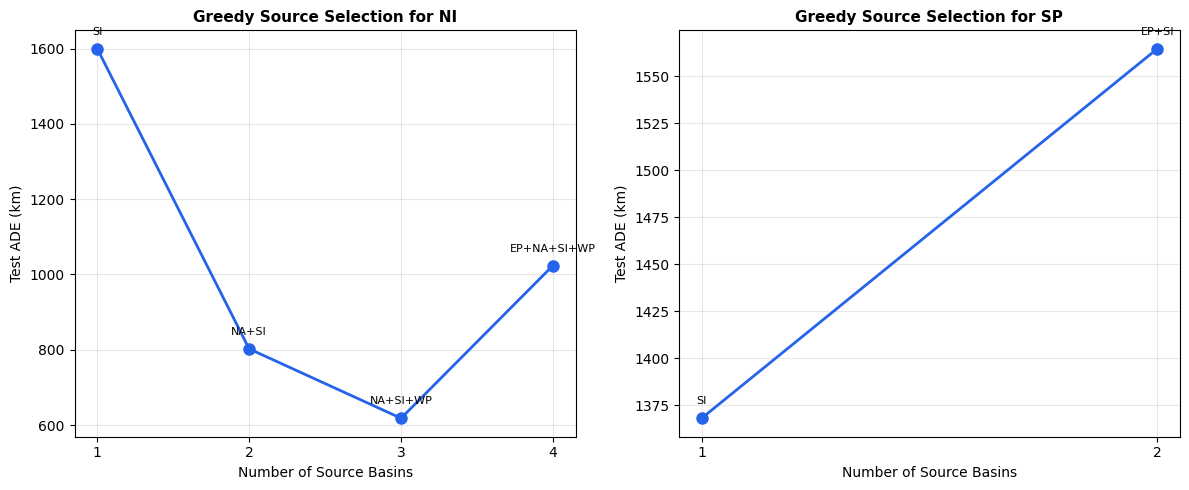

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (results, target) in zip(axes, [(ni_results, "NI"), (sp_results, "SP")]):
    if not results:
        continue
    x = list(range(1, len(results)+1))
    y = [r[1] for r in results]
    labels = ["+".join(sorted(r[0])) for r in results]

    ax.plot(x, y, "o-", color="#2563eb", lw=2, ms=8)
    for xi, yi, lab in zip(x, y, labels):
        ax.annotate(lab, (xi, yi), textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=8)
    ax.axhline(y=next((v["ade_km"] for k,v in {} .items()), float("nan")),
               color="gray", linestyle="--", alpha=0.5, label="Persistence")
    ax.set_title(f"Greedy Source Selection for {target}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Number of Source Basins")
    ax.set_ylabel("Test ADE (km)")
    ax.set_xticks(x)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS / "fig_greedy_selection.png", dpi=150, bbox_inches="tight")
plt.show()

## Findings & Conclusions

### 1. Transfer Matrix — Full 6×6 Results

Rows = training basin, Columns = test basin. Diagonal = within-basin performance.

| Train \ Test | EP | NA | NI | SI | SP | WP |
|---|---|---|---|---|---|---|
| **EP** | **904.9** | 2083.6 | 3175.2 | 2304.8 | 3423.6 | 2993.0 |
| **NA** | 2645.3 | **1331.0** | 707.3 | 2185.4 | 3145.7 | 3308.1 |
| **NI** | 3790.0 | 3396.8 | **588.3** | 1747.5 | 3326.5 | 1611.1 |
| **SI** | 2159.3 | 3658.6 | 700.3 | **974.6** | 1450.8 | 3429.0 |
| **SP** | 1878.1 | 3308.2 | 2851.8 | 4251.0 | **1667.2** | 2747.1 |
| **WP** | 2976.8 | 2496.7 | 1546.7 | 1444.4 | 3393.6 | **968.0** |

*(all values in km ADE — lower is better)*

---

### 2. MMD Basin Similarity vs Transfer Quality

| Pair | MMD² | Transfer Quality |
|---|---|---|
| NA ↔ WP | 0.0454 | Moderate (similar feature space, different geography) |
| NA ↔ SI | 0.0488 | Weak (hemisphere flip hurts) |
| SI ↔ WP | 0.0547 | Asymmetric — WP→SI=1444 km (good), SI→WP=3429 km (poor) |
| EP ↔ NI | 0.1001 | Very poor both ways |
| NI ↔ SP | 0.1020 | Worst pair — most dissimilar |

**MMD is a useful but imperfect proxy** — it predicts which pairs will fail (high MMD = bad transfer), but doesn't fully predict which direction works better. Transfer asymmetry is real and MMD misses it.

---

### 3. Critical Finding — SI → SP Beats SP → SP

| Model | Test ADE on SP |
|---|---|
| Trained on SP only (within-basin) | 1667.2 km |
| Trained on SI only (cross-basin) | **1450.8 km ← better** |
| Greedy: SI alone | **1368.0 km ← best** |

A model trained on South Indian Ocean data **outperforms** a model trained on South Pacific data when tested on SP. Why:
- SI has 3× more training data (1231 vs 418 samples, 53 vs 18 TCs)
- Both are Southern Hemisphere basins with similar poleward-equatorward drift patterns
- SP storms are too few to train a reliable model — SI provides more signal about the same physical dynamics

**For SP, cross-basin transfer is not just useful — it's mandatory.**

---

### 4. NI Greedy Source Selection

| Sources | ADE on NI |
|---|---|
| SI | 1599.3 km |
| SI + NA | 802.3 km (−49.8%) |
| SI + NA + WP | **618.0 km** (−23.0%) |
| SI + NA + WP + EP | 1023.5 km (WORSE — stopped) |

Optimal: **SI + NA + WP → 618 km** — within 5% of within-basin performance (588.3 km).  
NI only has 253 training samples. Three carefully chosen source basins essentially compensate for the data scarcity.  
Adding EP actually hurts (Eastern Pacific recurvature pattern confuses the model).

---

### 5. Best Single-Source Transfer for Each Target

| Target Basin | Best Source | Transfer ADE | Within-Basin ADE | Transfer Gap |
|---|---|---|---|---|
| NI | SI | 700.3 km | 588.3 km | +19% |
| SP | SI | 1450.8 km | 1667.2 km | **−13% (better!)** |
| SI | WP | 1444.4 km | 974.6 km | +48% |
| WP | NI | 1611.1 km | 968.0 km | +66% |
| NA | EP | 2083.6 km | 1331.0 km | +57% |
| EP | SP | 1878.1 km | 904.9 km | +108% |

**EP is the most isolated basin** — the best single-source transfer is 2× worse than within-basin, the largest gap of any basin. EP's eastward-recurving tracks over the northeastern Pacific have no analogue in the data.

---

### 6. Transfer is Asymmetric

Example: NI ↔ WP  
- NI → WP: **1611.1 km** (reasonable)  
- WP → NI: **1546.7 km** (also reasonable)  

Example: SI ↔ SP  
- SI → SP: **1450.8 km** (good)  
- SP → SI: **4251.0 km** (catastrophically bad)  

SP→SI fails because SP's 418-sample training set is too small to learn generalizable features. Data volume asymmetry causes directional transfer asymmetry more than geography does.

---

### 7. What This Means for Future Notebooks

| Implication | Impact on nb_03 / nb_04 |
|---|---|
| **SP must use SI as source** | LOBO for SP should weight SI data; any pooled baseline should include SI |
| **NI needs SI + NA + WP** | Three-source combination nearly matches within-basin — use all 5 basins for LOBO on NI |
| **EP is genuinely hard** | Domain generalization methods (IRM, CORAL) will struggle most here — set expectations accordingly |
| **MMD ~ transfer quality** | CORAL's covariance alignment should help most for NA↔WP↔SI cluster (most similar distributions) |
| **Asymmetry = data volume effect** | Adding more SP/NI data > any algorithmic improvement for those basins |
| **WP is self-sufficient** | WP has 2059 samples — within-basin already good; generalization methods add marginal value |
| **Basin groupings for DANN/CORAL** | Natural clusters: {WP, SI, NA} (similar MMD), {EP} (isolated), {NI, SP} (small/irregular) |